In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Descriptors import MolLogP
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import Descriptors
from rdkit.Chem import PandasTools
from rdkit.DataStructs import ExplicitBitVect

import sys
import multiprocessing
from standardiser import break_bonds, neutralise, rules, unsalt
from standardiser.utils import StandardiseException, sanity_check
def warn(*args, **kwargs):
    pass 
import warnings
warnings.filterwarnings("ignore")
warnings.warn = warn
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import sys
from sklearn.metrics import cohen_kappa_score
import csv
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import ShuffleSplit
import _pickle as cPickle
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit    
import bz2
from glob import glob
import _pickle as cPickle
import pickle





In [2]:
# Function to read SDF file into DataFrame
def load_sdf_to_df(filename):
    suppl = Chem.SDMolSupplier(filename)
    rows = []
    for mol in suppl:
        if mol is not None:
            row = {prop: mol.GetProp(prop) for prop in mol.GetPropNames()}
            row['SMILES'] = Chem.MolToSmiles(mol)
            rows.append(row)
    return pd.DataFrame(rows)

# Load the  test sets from SDF files
test_df = load_sdf_to_df(r'C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Skin Sensitization\dataset\test_set_skin_sensitization_features_rdkitcdk.sdf')

# Convert strings back to lists of integers
def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string


test_df['Morgan_Descriptors'] = test_df['Morgan_Descriptors'].apply(string_to_list)
test_df['MACCS_Descriptors'] = test_df['MACCS_Descriptors'].apply(string_to_list)

def string_to_list(descriptor):
    if isinstance(descriptor, str):
        return list(map(float, descriptor.strip('[]').split(',')))
    return descriptor

# Apply the function to the 'Modred_Descriptor' column
test_df['Modred_Descriptor'] = test_df['Modred_Descriptor'].apply(string_to_list)

# Convert 'Modred_Descriptor' column to a NumPy array
data_modred_test = np.array(test_df['Modred_Descriptor'].tolist())


print("Test DataFrame:")
print(test_df.head())


Test DataFrame:
                                       Compound name Outcome LLNA class RowID  \
0            2-cyclohexylsulfanylisoindole-1,3-dione       1              288   
1                             1,2-Diaminocyclohexane       1     Strong   196   
2  (2,4-dichlorobenzoyl) 2,4-dichlorobenzenecarbo...       1              179   
3                              Trimellitic anhydride       1   Moderate    52   
4          2-[4-(2-hydroxyethoxy)but-2-ynoxy]ethanol       1              286   

                                  Morgan_Descriptors  \
0  [0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
3  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
4  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...   

                                   MACCS_Descriptors  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [3]:
data_modred_test.shape

(199, 545)

In [4]:
test_df

,Compound name,Outcome,LLNA class,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,ID,SMILES,Molecular Weight,...,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3
0,"2-cyclohexylsulfanylisoindole-1,3-dione",1,,288,"[0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.0042457655443273136, 0.11801186580348445, ...",288,O=C1c2ccccc2C(=O)N1SC1CCCCC1,261.08234972,...,0.0,0.0,0.0,0.4444444444444444,2.0,0.0,62.68000000000001,5.321928094887363,3.5490000000000004,0.4285714285714285
1,"1,2-Diaminocyclohexane",1,Strong,196,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.9713079998634846, -0.8690458206165751, -0....",196,NC1CCCCC1N,114.11569844799999,...,2.0,0.0,0.0,0.25,0.0,0.0,52.04,4.0,-0.046,1.0
2,"(2,4-dichlorobenzoyl) 2,4-dichlorobenzenecarbo...",1,,179,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.5610715773768501, 0.7132257856329035, 0.558...",179,O=C(OOC(=O)c1ccc(Cl)cc1Cl)c1ccc(Cl)cc1Cl,377.902019392,...,0.0,0.0,6.0,0.4615384615384615,5.0,1.0,52.6,5.523561956057013,5.808000000000001,0.0
3,Trimellitic anhydride,1,Moderate,52,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.35917252633357244, 0.3550611526996406, 0.45...",52,O=C(O)c1ccc2c(c1)C(=O)OC2=O,192.005873228,...,1.0,0.0,3.0,0.4285714285714285,1.0,0.0,80.66999999999999,4.906890595608519,1.138,0.0
4,2-[4-(2-hydroxyethoxy)but-2-ynoxy]ethanol,1,,286,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.27280572361002964, -0.5367882135736023, -0...",286,OCCOCC#CCOCCO,174.089208928,...,2.0,4.0,12.0,0.4545454545454545,6.0,0.0,58.92,4.459431618637298,-1.2600000000000002,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194,Cyclopentanepropanol,0,Non-sensitizer,846,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.9158713112719405, -0.886533063092521, -0.8...",846,OCCCC1CCCC1,128.120115132,...,1.0,3.0,4.0,0.5,3.0,0.0,20.23,4.169925001442312,2.7259999999999995,1.0
195,Indanthrene blue,0,,877,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.7340024034038648, 2.2378542592764865, 2.348...",877,O=c1c2ccccc2c(=O)c2c1ccc1[nH]c3c(ccc4c(=O)c5cc...,442.095356928,...,2.0,0.0,0.0,0.4666666666666667,0.0,1.0,92.34,6.321928094887363,5.354000000000001,0.0
196,"3'-[(2z)-[1-(3,4-dimethylphenyl)-1,5-dihydro-3...",0,Non-sensitizer,746,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.5011683113193799, 1.853134924805676, 1.6670...",746,Cc1ccc(-n2[nH]c(C)c(/N=N/c3cccc(-c4cccc(C(=O)O...,442.1641051839999,...,3.0,0.0,3.0,0.4705882352941176,5.0,1.0,120.04,6.169925001442312,6.4110000000000005,0.12
197,"(3R,6Rr)-3-(2,3-dihydro-1H-inden-2-yl)-1-[(1R)...",0,Non-sensitizer,562,"[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.5344303244743063, 1.701578823347478, 1.5655...",562,CCC(C)C1C(=O)NC(C2Cc3ccccc3C2)C(=O)N1C(C(=O)N1...,494.25292018799996,...,1.0,4.0,4.0,0.4615384615384615,7.0,0.0,104.98,6.321928094887363,1.5930000000000002,0.5555555555555556


In [5]:
test_df = test_df.rename(columns={'Outcome': 'Outcome'})

Classes                          :  ['0' '1']
Number of cpds in each class     :  [ 99 100]
Total number of cpds             :  199


{'1': 0, '0': 1}

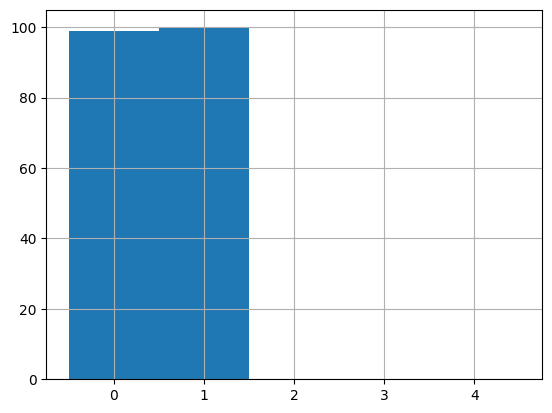

In [6]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()


outcomes=(np.unique(test_df['Outcome']))
le.fit(list(set(outcomes)))
y = le.transform( test_df['Outcome'] )



print ("Classes                          : ",(outcomes))
print ("Number of cpds in each class     : ",np.unique([len(y[y==smi]) for smi in y]))
print ("Total number of cpds             : ",len(y))

S = test_df['Outcome']
info = {}
for i,cls in enumerate(S.unique()):
    info.update({cls:i})
    S = S.replace(cls,i)

#graph
ax = S.hist(bins=np.arange(-0.5,5))
ax.set_xticks(range(0,5))
info

In [7]:
test_df

,Compound name,Outcome,LLNA class,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,ID,SMILES,Molecular Weight,...,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3
0,"2-cyclohexylsulfanylisoindole-1,3-dione",1,,288,"[0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.0042457655443273136, 0.11801186580348445, ...",288,O=C1c2ccccc2C(=O)N1SC1CCCCC1,261.08234972,...,0.0,0.0,0.0,0.4444444444444444,2.0,0.0,62.68000000000001,5.321928094887363,3.5490000000000004,0.4285714285714285
1,"1,2-Diaminocyclohexane",1,Strong,196,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.9713079998634846, -0.8690458206165751, -0....",196,NC1CCCCC1N,114.11569844799999,...,2.0,0.0,0.0,0.25,0.0,0.0,52.04,4.0,-0.046,1.0
2,"(2,4-dichlorobenzoyl) 2,4-dichlorobenzenecarbo...",1,,179,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.5610715773768501, 0.7132257856329035, 0.558...",179,O=C(OOC(=O)c1ccc(Cl)cc1Cl)c1ccc(Cl)cc1Cl,377.902019392,...,0.0,0.0,6.0,0.4615384615384615,5.0,1.0,52.6,5.523561956057013,5.808000000000001,0.0
3,Trimellitic anhydride,1,Moderate,52,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.35917252633357244, 0.3550611526996406, 0.45...",52,O=C(O)c1ccc2c(c1)C(=O)OC2=O,192.005873228,...,1.0,0.0,3.0,0.4285714285714285,1.0,0.0,80.66999999999999,4.906890595608519,1.138,0.0
4,2-[4-(2-hydroxyethoxy)but-2-ynoxy]ethanol,1,,286,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.27280572361002964, -0.5367882135736023, -0...",286,OCCOCC#CCOCCO,174.089208928,...,2.0,4.0,12.0,0.4545454545454545,6.0,0.0,58.92,4.459431618637298,-1.2600000000000002,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194,Cyclopentanepropanol,0,Non-sensitizer,846,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.9158713112719405, -0.886533063092521, -0.8...",846,OCCCC1CCCC1,128.120115132,...,1.0,3.0,4.0,0.5,3.0,0.0,20.23,4.169925001442312,2.7259999999999995,1.0
195,Indanthrene blue,0,,877,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.7340024034038648, 2.2378542592764865, 2.348...",877,O=c1c2ccccc2c(=O)c2c1ccc1[nH]c3c(ccc4c(=O)c5cc...,442.095356928,...,2.0,0.0,0.0,0.4666666666666667,0.0,1.0,92.34,6.321928094887363,5.354000000000001,0.0
196,"3'-[(2z)-[1-(3,4-dimethylphenyl)-1,5-dihydro-3...",0,Non-sensitizer,746,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.5011683113193799, 1.853134924805676, 1.6670...",746,Cc1ccc(-n2[nH]c(C)c(/N=N/c3cccc(-c4cccc(C(=O)O...,442.1641051839999,...,3.0,0.0,3.0,0.4705882352941176,5.0,1.0,120.04,6.169925001442312,6.4110000000000005,0.12
197,"(3R,6Rr)-3-(2,3-dihydro-1H-inden-2-yl)-1-[(1R)...",0,Non-sensitizer,562,"[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.5344303244743063, 1.701578823347478, 1.5655...",562,CCC(C)C1C(=O)NC(C2Cc3ccccc3C2)C(=O)N1C(C(=O)N1...,494.25292018799996,...,1.0,4.0,4.0,0.4615384615384615,7.0,0.0,104.98,6.321928094887363,1.5930000000000002,0.5555555555555556


In [8]:
#load model - all included
import joblib

# Base paths
fingerprint_path = r"C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Skin Sensitization\model\fingerprint descriptor model"
phys_path        = r"C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Skin Sensitization\model\physical chemical properties model"

# descriptor
rf_morgan   = joblib.load(fr"{fingerprint_path}\Model_Skin_sens_RF_morgan.pkl")  
rf_maccskey    = joblib.load(fr"{fingerprint_path}\Model_Skin_sens_RF_maccskey.pkl")
rf_modred   = joblib.load(fr"{fingerprint_path}\Model_Skin_sens_RF_modred.pkl")

svm_morgan  = joblib.load(fr"{fingerprint_path}\Model_Skin_sens_SVM_morgan.pkl")  
svm_maccskey   = joblib.load(fr"{fingerprint_path}\Model_Skin_sens_SVM_maccskey.pkl")
svm_modred  = joblib.load(fr"{fingerprint_path}\Model_Skin_sens_SVM_modred.pkl")

xgb_morgan  = joblib.load(fr"{fingerprint_path}\Model_Skin_sens_XGB_morgan.pkl")  
xgb_maccskey   = joblib.load(fr"{fingerprint_path}\Model_Skin_sens_XGB_maccskey.pkl")
xgb_modred  = joblib.load(fr"{fingerprint_path}\Model_Skin_sens_XGB_modred.pkl")

nn_morgan   = joblib.load(fr"{fingerprint_path}\Model_Skin_sens_NN_morgan.pkl")  
nn_maccskey    = joblib.load(fr"{fingerprint_path}\Model_Skin_sens_NN_maccskey.pkl")
nn_modred   = joblib.load(fr"{fingerprint_path}\Model_Skin_sens_NN_modred.pkl")

lgbm_morgan = joblib.load(fr"{fingerprint_path}\Model_Skin_sens_LGBM_morgan.pkl")  
lgbm_maccskey  = joblib.load(fr"{fingerprint_path}\Model_Skin_sens_LGBM_maccskey.pkl")
lgbm_modred = joblib.load(fr"{fingerprint_path}\Model_Skin_sens_LGBM_modred.pkl")

# physiochemical
rf_phys   = joblib.load(fr"{phys_path}\Model_Skin_sens_RF_rdkit_cdk.pkl")
svm_phys  = joblib.load(fr"{phys_path}\Model_Skin_sens_SVM_rdkit_cdk.pkl")
xgb_phys  = joblib.load(fr"{phys_path}\Model_Skin_sens_XGB_rdkit_cdk.pkl")
nn_phys   = joblib.load(fr"{phys_path}\Model_Skin_sens_NN_rdkit_cdk.pkl")
lgbm_phys = joblib.load(fr"{phys_path}\Model_Skin_sens_LGBM_rdkit_cdk.pkl")


In [9]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score, classification_report
y_true = test_df['Outcome'].astype(int) 


In [11]:
# RF
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

def predict_probabilities_rf_from_pkl(test_df, rf_morgan, rf_maccskey, rf_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :rf_morgan.n_features_in_]

    X_maccskey = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :rf_maccskey.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :rf_modred.n_features_in_]

    return {
        "Morgan":   rf_morgan.predict_proba(X_morgan)[:, 1],
        "MACCSkey": rf_maccskey.predict_proba(X_maccskey)[:, 1],
        "Modred":   rf_modred.predict_proba(X_modred)[:, 1]
    }

def evaluate_model(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs_rf = predict_probabilities_rf_from_pkl(
    test_df,
    rf_morgan,
    rf_maccskey,
    rf_modred
)

for model_name, y_prob in probs_rf.items():
    print(f"\n{model_name} RF Performance")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

consensus_probs_rf = consensus_probability(probs_rf)
consensus_metrics_rf = evaluate_model(y_true, consensus_probs_rf)

print("\nCONSENSUS RF (Morgan + MACCSkey + Modred)")
for k, v in consensus_metrics_rf.items():
    print(f"{k}: {v}")



Morgan RF Performance
Confusion Matrix: [[56 44]
 [34 65]]
Accuracy: 0.6080402010050251
AUC: 0.6544444444444444
F1 Score: 0.625
Sensitivity: 0.6565656565656566
Specificity: 0.56
CCR: 0.6082828282828283
PPV (Precision): 0.5963302752293578
NPV: 0.6222222222222222

MACCSkey RF Performance
Confusion Matrix: [[72 28]
 [36 63]]
Accuracy: 0.678391959798995
AUC: 0.7275757575757577
F1 Score: 0.6631578947368421
Sensitivity: 0.6363636363636364
Specificity: 0.72
CCR: 0.6781818181818182
PPV (Precision): 0.6923076923076923
NPV: 0.6666666666666666

Modred RF Performance
Confusion Matrix: [[71 29]
 [30 69]]
Accuracy: 0.7035175879396985
AUC: 0.7752525252525252
F1 Score: 0.700507614213198
Sensitivity: 0.696969696969697
Specificity: 0.71
CCR: 0.7034848484848485
PPV (Precision): 0.7040816326530612
NPV: 0.7029702970297029

CONSENSUS RF (Morgan + MACCSkey + Modred)
Confusion Matrix: [[70 30]
 [33 66]]
Accuracy: 0.6834170854271356
AUC: 0.7535353535353535
F1 Score: 0.676923076923077
Sensitivity: 0.6666666666

In [12]:
# SVM
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

def predict_probabilities_from_pkl(test_df, svm_morgan, svm_maccskey, svm_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :svm_morgan.n_features_in_]

    X_maccskey = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :svm_maccskey.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :svm_modred.n_features_in_]

    return {
        "Morgan":   svm_morgan.predict_proba(X_morgan)[:, 1],
        "MACCSkey": svm_maccskey.predict_proba(X_maccskey)[:, 1],
        "Modred":   svm_modred.predict_proba(X_modred)[:, 1]
    }

def evaluate_model(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs_svm = predict_probabilities_from_pkl(
    test_df,
    svm_morgan,
    svm_maccskey,
    svm_modred
)

for model_name, y_prob in probs_svm.items():
    print(f"\n{model_name} SVM Performance")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

consensus_probs_svm = consensus_probability(probs_svm)
consensus_metrics_svm = evaluate_model(y_true, consensus_probs_svm)

print("\nCONSENSUS SVM (Morgan + MACCSkey + Modred)")
for k, v in consensus_metrics_svm.items():
    print(f"{k}: {v}")



Morgan SVM Performance
Confusion Matrix: [[65 35]
 [39 60]]
Accuracy: 0.628140703517588
AUC: 0.7168686868686869
F1 Score: 0.6185567010309279
Sensitivity (Recall+): 0.6060606060606061
Specificity (Recall-): 0.65
CCR: 0.628030303030303
PPV (Precision): 0.631578947368421
NPV: 0.625

MACCSkey SVM Performance
Confusion Matrix: [[65 35]
 [39 60]]
Accuracy: 0.628140703517588
AUC: 0.719090909090909
F1 Score: 0.6185567010309279
Sensitivity (Recall+): 0.6060606060606061
Specificity (Recall-): 0.65
CCR: 0.628030303030303
PPV (Precision): 0.631578947368421
NPV: 0.625

Modred SVM Performance
Confusion Matrix: [[67 33]
 [29 70]]
Accuracy: 0.6884422110552764
AUC: 0.76010101010101
F1 Score: 0.693069306930693
Sensitivity (Recall+): 0.7070707070707071
Specificity (Recall-): 0.67
CCR: 0.6885353535353536
PPV (Precision): 0.6796116504854369
NPV: 0.6979166666666666

CONSENSUS SVM (Morgan + MACCSkey + Modred)
Confusion Matrix: [[67 33]
 [34 65]]
Accuracy: 0.6633165829145728
AUC: 0.7587878787878788
F1 Score:

In [13]:
# XGB
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

def predict_probabilities_from_pkl(test_df, xgb_morgan, xgb_maccskey, xgb_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :xgb_morgan.n_features_in_]

    X_maccskey = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :xgb_maccskey.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :xgb_modred.n_features_in_]

    return {
        "Morgan":   xgb_morgan.predict_proba(X_morgan)[:, 1],
        "MACCSkey": xgb_maccskey.predict_proba(X_maccskey)[:, 1],
        "Modred":   xgb_modred.predict_proba(X_modred)[:, 1]
    }

def evaluate_model(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs_xgb = predict_probabilities_from_pkl(
    test_df,
    xgb_morgan,
    xgb_maccskey,
    xgb_modred
)

for model_name, y_prob in probs_xgb.items():
    print(f"\n{model_name} XGB Performance")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

consensus_probs_xgb = consensus_probability(probs_xgb)
consensus_metrics_xgb = evaluate_model(y_true, consensus_probs_xgb)

print("\nCONSENSUS XGB (Morgan + MACCSkey + Modred)")
for k, v in consensus_metrics_xgb.items():
    print(f"{k}: {v}")



Morgan XGB Performance
Confusion Matrix: [[61 39]
 [39 60]]
Accuracy: 0.6080402010050251
AUC: 0.6670202020202021
F1 Score: 0.6060606060606061
Sensitivity (Recall+): 0.6060606060606061
Specificity (Recall-): 0.61
CCR: 0.608030303030303
PPV (Precision): 0.6060606060606061
NPV: 0.61

MACCSkey XGB Performance
Confusion Matrix: [[66 34]
 [36 63]]
Accuracy: 0.6482412060301508
AUC: 0.7503030303030304
F1 Score: 0.6428571428571429
Sensitivity (Recall+): 0.6363636363636364
Specificity (Recall-): 0.66
CCR: 0.6481818181818182
PPV (Precision): 0.6494845360824743
NPV: 0.6470588235294118

Modred XGB Performance
Confusion Matrix: [[69 31]
 [35 64]]
Accuracy: 0.6683417085427136
AUC: 0.7565656565656566
F1 Score: 0.6597938144329897
Sensitivity (Recall+): 0.6464646464646465
Specificity (Recall-): 0.69
CCR: 0.6682323232323233
PPV (Precision): 0.6736842105263158
NPV: 0.6634615384615384

CONSENSUS XGB (Morgan + MACCSkey + Modred)
Confusion Matrix: [[66 34]
 [37 62]]
Accuracy: 0.6432160804020101
AUC: 0.76676

In [14]:
# NN 
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

def predict_probabilities_from_pkl(test_df, nn_morgan, nn_maccskey, nn_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :nn_morgan.n_features_in_]

    X_maccskey = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :nn_maccskey.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :nn_modred.n_features_in_]

    return {
        "Morgan":   nn_morgan.predict_proba(X_morgan)[:, 1],
        "MACCSkey": nn_maccskey.predict_proba(X_maccskey)[:, 1],
        "Modred":   nn_modred.predict_proba(X_modred)[:, 1]
    }

def evaluate_model(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs = predict_probabilities_from_pkl(
    test_df,
    nn_morgan,
    nn_maccskey,
    nn_modred
)

for model_name, y_prob in probs.items():
    print(f"\n{model_name} NN Performance")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

consensus_probs_nn = consensus_probability(probs)
consensus_metrics_nn = evaluate_model(y_true, consensus_probs_nn)

print("\nCONSENSUS NN (Morgan + MACCSkey + Modred)")
for k, v in consensus_metrics_nn.items():
    print(f"{k}: {v}")



Morgan NN Performance
Confusion Matrix: [[60 40]
 [35 64]]
Accuracy: 0.6231155778894473
AUC: 0.6865656565656566
F1 Score: 0.6305418719211823
Sensitivity (Recall+): 0.6464646464646465
Specificity (Recall-): 0.6
CCR: 0.6232323232323232
PPV (Precision): 0.6153846153846154
NPV: 0.631578947368421

MACCSkey NN Performance
Confusion Matrix: [[73 27]
 [36 63]]
Accuracy: 0.6834170854271356
AUC: 0.7371717171717171
F1 Score: 0.6666666666666666
Sensitivity (Recall+): 0.6363636363636364
Specificity (Recall-): 0.73
CCR: 0.6831818181818181
PPV (Precision): 0.7
NPV: 0.6697247706422018

Modred NN Performance
Confusion Matrix: [[76 24]
 [36 63]]
Accuracy: 0.6984924623115578
AUC: 0.75010101010101
F1 Score: 0.6774193548387096
Sensitivity (Recall+): 0.6363636363636364
Specificity (Recall-): 0.76
CCR: 0.6981818181818182
PPV (Precision): 0.7241379310344828
NPV: 0.6785714285714286

CONSENSUS NN (Morgan + MACCSkey + Modred)
Confusion Matrix: [[74 26]
 [31 68]]
Accuracy: 0.7135678391959799
AUC: 0.7707070707070

In [15]:
# LGBM 
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

def predict_probabilities_from_pkl(test_df, lgbm_morgan, lgbm_maccskey, lgbm_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :lgbm_morgan.n_features_in_]

    X_maccskey = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :lgbm_maccskey.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :lgbm_modred.n_features_in_]

    return {
        "Morgan":   lgbm_morgan.predict_proba(X_morgan)[:, 1],
        "MACCSkey": lgbm_maccskey.predict_proba(X_maccskey)[:, 1],
        "Modred":   lgbm_modred.predict_proba(X_modred)[:, 1]
    }

def evaluate_model(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs = predict_probabilities_from_pkl(
    test_df,
    lgbm_morgan,
    lgbm_maccskey,
    lgbm_modred
)

for model_name, y_prob in probs.items():
    print(f"\n===== {model_name} LGBM Performance =====")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

consensus_probs_lgbm = consensus_probability(probs)
consensus_metrics_lgbm = evaluate_model(y_true, consensus_probs_lgbm)

print("\n===== CONSENSUS LGBM (Morgan + MACCSkey + Modred) =====")
for k, v in consensus_metrics_lgbm.items():
    print(f"{k}: {v}")



===== Morgan LGBM Performance =====
Confusion Matrix: [[60 40]
 [40 59]]
Accuracy: 0.5979899497487438
AUC: 0.6827777777777777
F1 Score: 0.5959595959595959
Sensitivity (Recall+): 0.5959595959595959
Specificity (Recall-): 0.6
CCR: 0.597979797979798
PPV (Precision): 0.5959595959595959
NPV: 0.6

===== MACCSkey LGBM Performance =====
Confusion Matrix: [[63 37]
 [37 62]]
Accuracy: 0.628140703517588
AUC: 0.705858585858586
F1 Score: 0.6262626262626263
Sensitivity (Recall+): 0.6262626262626263
Specificity (Recall-): 0.63
CCR: 0.6281313131313131
PPV (Precision): 0.6262626262626263
NPV: 0.63

===== Modred LGBM Performance =====
Confusion Matrix: [[70 30]
 [36 63]]
Accuracy: 0.6683417085427136
AUC: 0.766060606060606
F1 Score: 0.65625
Sensitivity (Recall+): 0.6363636363636364
Specificity (Recall-): 0.7
CCR: 0.6681818181818182
PPV (Precision): 0.6774193548387096
NPV: 0.660377358490566

===== CONSENSUS LGBM (Morgan + MACCSkey + Modred) =====
Confusion Matrix: [[68 32]
 [35 64]]
Accuracy: 0.663316582

In [21]:
# CONSENSUS ALL (RF + SVM + XGB + NN + LGBM)
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# ==============================
# Evaluation Function
# ==============================
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# ==============================
# STACK ALL MODEL CONSENSUS
# ==============================
all_model_probs = np.vstack([
    consensus_probs_rf,
    consensus_probs_svm,
    consensus_probs_xgb,
    consensus_probs_nn,
    consensus_probs_lgbm
])

# ==============================
# FINAL CONSENSUS (MEAN)
# ==============================
consensus_all_probs = all_model_probs.mean(axis=0)

# ==============================
# EVALUATION
# ==============================
consensus_all_metrics = evaluate_model(y_true, consensus_all_probs)

print("CONSENSUS DESKRIPTOR (RF + SVM + XGB + NN + LGBM)")
for k, v in consensus_all_metrics.items():
    print(f"{k}: {v}")


CONSENSUS DESKRIPTOR (RF + SVM + XGB + NN + LGBM)
Confusion Matrix: [[74 26]
 [31 68]]
Accuracy: 0.7135678391959799
AUC: 0.7797979797979799
F1 Score: 0.7046632124352331
Sensitivity (Recall+): 0.6868686868686869
Specificity (Recall-): 0.74
CCR: 0.7134343434343434
PPV (Precision): 0.723404255319149
NPV: 0.7047619047619048
